# Assignment 3 — Phase 2:
## Student Name : Nakul Sidiginamola
## Student ID : 25750807

This notebook contains two image captioning architectures:
- **Model 1:** Custom CNN Encoder + LSTM Decoder (trained from scratch, greedy decoding)
- **Model 2:** ResNet34 Encoder (pretrained, fine-tuned) + LSTM Decoder with Beam Search

Both models are evaluated using BLEU-1 through BLEU-4 on the shared test split produced in Phase 1.

---
## 0. Imports and Configuration

In [3]:
import os
import re
import json
import random
import pickle
import string
import math
import ast
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence

import torchvision.transforms as transforms
import torchvision.models as models

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
CURRENT_DIR   = Path.home()
PROJECT_ROOT  = CURRENT_DIR / "Downloads" / "DL AT3"
IMAGE_DIR     = PROJECT_ROOT / "val" / "val"
ARTEFACTS_DIR = PROJECT_ROOT / "artefacts"

assert IMAGE_DIR.exists(),     f"Image directory not found: {IMAGE_DIR}"
assert ARTEFACTS_DIR.exists(), f"Artefacts directory not found: {ARTEFACTS_DIR}"

print("Project root: ", PROJECT_ROOT)
print("Image dir:    ", IMAGE_DIR)
print("Artefacts:    ", ARTEFACTS_DIR)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nTorch version : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device        : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Project root:  C:\Users\nakul\Downloads\DL AT3
Image dir:     C:\Users\nakul\Downloads\DL AT3\val\val
Artefacts:     C:\Users\nakul\Downloads\DL AT3\artefacts

Torch version : 2.10.0+cu130
CUDA available: True
Device        : cuda
GPU           : NVIDIA GeForce RTX 2050
VRAM          : 4.3 GB


---
## 1. Load Phase 1 Artefacts

We load the vocabulary, splits, and processed captions produced in the shared Phase 1 notebook.
No data preparation is repeated here — this keeps our pipeline reproducible and ensures identical
splits across all group members.

In [5]:
# ── 1.1  Vocabulary ───────────────────────────────────────────────────────────
with open(ARTEFACTS_DIR / "vocab.pkl", "rb") as f:
    vocab_data = pickle.load(f)

if "stoi" in vocab_data:
    word2idx = vocab_data["stoi"]
    idx2word = vocab_data["itos"]
else:
    word2idx = vocab_data["word2idx"]
    idx2word = vocab_data["idx2word"]

if isinstance(idx2word, dict):
    idx2word = [idx2word[i] for i in range(len(idx2word))]

VOCAB_SIZE = len(word2idx)
PAD_IDX    = vocab_data.get("pad_idx",  word2idx.get("<PAD>",  0))
START_IDX  = vocab_data.get("sos_idx",  word2idx.get("<START>", 1))
END_IDX    = vocab_data.get("eos_idx",  word2idx.get("<END>",   2))
UNK_IDX    = vocab_data.get("unk_idx",  word2idx.get("<UNK>",   3))

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Special indices : PAD={PAD_IDX}  START={START_IDX}  END={END_IDX}  UNK={UNK_IDX}")

# ── 1.2  Train / Val / Test splits ───────────────────────────────────────────
with open(ARTEFACTS_DIR / "splits.json", "r") as f:
    splits = json.load(f)

train_ids = set(int(x) for x in splits["train"])
val_ids   = set(int(x) for x in splits["val"])
test_ids  = set(int(x) for x in splits["test"])

print(f"\nSplit sizes — train: {len(train_ids)}  val: {len(val_ids)}  test: {len(test_ids)}")

# ── 1.3  Processed captions ───────────────────────────────────────────────────
df = pd.read_csv(ARTEFACTS_DIR / "captions_processed.csv")
if isinstance(df["tokens"].iloc[0], str):
    df["tokens"] = df["tokens"].apply(ast.literal_eval)

print(f"\nCaptions dataframe: {df.shape}")
print(df.head(3))

# ── 1.4  id_to_filename and id_to_tokens ─────────────────────────────────────
with open(ARTEFACTS_DIR / "id_to_tokens.json", "r") as f:
    raw_map = json.load(f)

id_to_tokens: Dict[int, List[List[str]]] = {int(k): v for k, v in raw_map.items()}

id_to_filename: Dict[int, str] = (
    df.drop_duplicates("image_id")[["image_id", "file_name"]]
      .set_index("image_id")["file_name"]
      .to_dict()
)

print(f"\nid_to_tokens entries : {len(id_to_tokens)}")
print(f"id_to_filename entries: {len(id_to_filename)}")

Vocabulary size : 3274
Special indices : PAD=0  START=1  END=2  UNK=3

Split sizes — train: 5425  val: 1162  test: 1163

Captions dataframe: (38750, 8)
   image_id                file_name  \
0     23431  VizWiz_val_00000000.jpg   
1     23431  VizWiz_val_00000000.jpg   
2     23431  VizWiz_val_00000000.jpg   

                                             caption  \
0  A computer screen shows a repair prompt on the...   
1  a computer screen with a repair automatically ...   
2  partial computer screen showing the need of re...   

                                       caption_clean  \
0  a computer screen shows a repair prompt on the...   
1  a computer screen with a repair automatically ...   
2  partial computer screen showing the need of re...   

                                              tokens  token_length  \
0  [a, computer, screen, shows, a, repair, prompt...            10   
1  [a, computer, screen, with, a, repair, automat...             9   
2  [partial, computer, scre

---
## 2. Shared Utilities

In [7]:
# ── 2.1  Vocabulary helpers ───────────────────────────────────────────────────
def encode_caption(tokens: List[str], max_len: int = 50) -> torch.LongTensor:
    ids = [START_IDX]
    for t in tokens[:max_len]:
        ids.append(word2idx.get(t, UNK_IDX))
    ids.append(END_IDX)
    return torch.tensor(ids, dtype=torch.long)


def decode_caption(indices) -> str:
    skip  = {PAD_IDX, START_IDX, END_IDX, UNK_IDX}
    words = []
    for idx in indices:
        i = int(idx)
        if i == END_IDX:
            break
        if i not in skip:
            words.append(idx2word[i] if i < len(idx2word) else "<UNK>")
    return " ".join(words)


print("Vocabulary helpers defined.")

Vocabulary helpers defined.


In [8]:
# ── 2.2  Image Transforms ─────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined.")

Transforms defined.


In [9]:
# ── 2.3  Dataset and Collate ──────────────────────────────────────────────────
MAX_CAPTION_LEN = 50

class VizWizDataset(Dataset):
    """
    Training mode : returns (image, caption_tensor, length) — 1 random caption.
    Eval mode     : returns (image, all_5_captions, lengths) — for multi-ref BLEU.
    """
    def __init__(self, image_ids, id_to_filename, id_to_tokens,
                 image_dir, transform, training=True, max_len=MAX_CAPTION_LEN):
        self.id_to_filename = id_to_filename
        self.id_to_tokens   = id_to_tokens
        self.image_dir      = image_dir
        self.transform      = transform
        self.training       = training
        self.max_len        = max_len
        self.image_ids = [
            iid for iid in image_ids
            if (image_dir / id_to_filename[iid]).exists()
        ]
        print(f"Dataset ({'train' if training else 'eval'}): {len(self.image_ids)} images loaded.")

    def _load_image(self, iid):
        return self.transform(
            Image.open(self.image_dir / self.id_to_filename[iid]).convert("RGB")
        )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        iid   = self.image_ids[idx]
        image = self._load_image(iid)
        caps  = self.id_to_tokens[iid]
        if self.training:
            enc    = encode_caption(random.choice(caps), self.max_len)
            return image, enc, torch.tensor(len(enc), dtype=torch.long)
        else:
            all_enc = [encode_caption(c, self.max_len) for c in caps]
            lengths = torch.tensor([len(e) for e in all_enc], dtype=torch.long)
            return image, all_enc, lengths


def collate_train(batch):
    images, captions, lengths = zip(*batch)
    return (torch.stack(images),
            pad_sequence(captions, batch_first=True, padding_value=PAD_IDX),
            torch.stack(lengths))


def collate_eval(batch):
    images, all_captions, all_lengths = zip(*batch)
    return torch.stack(images), list(all_captions), torch.stack(all_lengths)


print("Dataset and collate functions defined.")

Dataset and collate functions defined.


In [10]:
# ── 2.4  Instantiate datasets and dataloaders ─────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 0

train_dataset = VizWizDataset(list(train_ids), id_to_filename, id_to_tokens,
                               IMAGE_DIR, train_transform, training=True)
val_dataset   = VizWizDataset(list(val_ids),   id_to_filename, id_to_tokens,
                               IMAGE_DIR, eval_transform,  training=False)
test_dataset  = VizWizDataset(list(test_ids),  id_to_filename, id_to_tokens,
                               IMAGE_DIR, eval_transform,  training=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_train, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_eval)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_eval)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Dataset (train): 5425 images loaded.
Dataset (eval): 1162 images loaded.
Dataset (eval): 1163 images loaded.

Train batches : 169
Val batches   : 37
Test batches  : 37


In [11]:
# ── 2.5  Decoding utilities ───────────────────────────────────────────────────

def greedy_decode(decoder, feature, device, max_len=50):
    decoder.eval()
    words = []
    with torch.no_grad():
        hidden = decoder.init_hidden(feature)
        inp    = torch.tensor([[START_IDX]], dtype=torch.long, device=device)
        for _ in range(max_len):
            out, hidden = decoder.step(inp, hidden)
            pred = out.argmax(dim=-1)      # (1,)
            idx  = pred.item()
            if idx == END_IDX:
                break
            if idx not in {PAD_IDX, START_IDX, UNK_IDX} and idx < len(idx2word):
                words.append(idx2word[idx])
            inp = pred.view(1, 1)
    return words


def beam_search_decode(decoder, feature, device, max_len=50, beam_width=5):
    decoder.eval()
    with torch.no_grad():
        hidden    = decoder.init_hidden(feature)
        # (cumulative_log_prob, token_id_list, hidden_state)
        beams     = [(0.0, [START_IDX], hidden)]
        completed = []

        for _ in range(max_len):
            new_beams = []
            for log_prob, tokens, hid in beams:
                if tokens[-1] == END_IDX:
                    completed.append((log_prob, tokens))
                    continue
                inp = torch.tensor([[tokens[-1]]], dtype=torch.long, device=device)
                out, new_hid = decoder.step(inp, hid)         # (1, vocab_size)
                lp = F.log_softmax(out, dim=-1).squeeze(0)    # (vocab_size,)
                topk_lp, topk_ids = lp.topk(beam_width)
                for i in range(beam_width):
                    new_beams.append((
                        log_prob + topk_lp[i].item(),
                        tokens + [topk_ids[i].item()],
                        new_hid
                    ))

            if not new_beams:
                break
            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:beam_width]

        for log_prob, tokens, _ in beams:
            completed.append((log_prob, tokens))

        completed.sort(key=lambda x: x[0], reverse=True)
        best_tokens = completed[0][1]

        words = []
        for idx in best_tokens:
            if idx == END_IDX:
                break
            if idx not in {PAD_IDX, START_IDX, UNK_IDX} and idx < len(idx2word):
                words.append(idx2word[idx])
        return words


print("Decoding utilities defined.")

Decoding utilities defined.


In [12]:
# ── 2.6  BLEU evaluation ──────────────────────────────────────────────────────
def evaluate_bleu(model_encoder, model_decoder, loader, device,
                  max_len=50, decode_fn=None):
    """
    Corpus-level BLEU-1 through BLEU-4.
    decode_fn: callable(decoder, feature, device) -> List[str]
               Defaults to greedy_decode if None.
    """
    model_encoder.eval()
    model_decoder.eval()
    if decode_fn is None:
        decode_fn = lambda dec, feat, dev: greedy_decode(dec, feat, dev, max_len)

    all_hypotheses = []
    all_references = []

    with torch.no_grad():
        for images, all_caps_batch, _ in tqdm(loader, desc="Evaluating", leave=False):
            images   = images.to(device)
            features = model_encoder(images)
            B        = images.size(0)

            for i in range(B):
                feat = features[i].unsqueeze(0)
                hyp  = decode_fn(model_decoder, feat, device)
                all_hypotheses.append(hyp)

                refs = []
                for cap_tensor in all_caps_batch[i]:
                    ref_toks = [
                        idx2word[idx] if idx < len(idx2word) else "<UNK>"
                        for idx in cap_tensor.tolist()
                        if idx not in {PAD_IDX, START_IDX, END_IDX, UNK_IDX}
                    ]
                    # stop at END
                    end_pos = next(
                        (j for j, ix in enumerate(cap_tensor.tolist()) if ix == END_IDX),
                        len(cap_tensor)
                    )
                    ref_toks = [
                        idx2word[ix] if ix < len(idx2word) else "<UNK>"
                        for ix in cap_tensor.tolist()[:end_pos]
                        if ix not in {PAD_IDX, START_IDX, UNK_IDX}
                    ]
                    refs.append(ref_toks)
                all_references.append(refs)

    bleu1 = corpus_bleu(all_references, all_hypotheses, weights=(1, 0, 0, 0))
    bleu2 = corpus_bleu(all_references, all_hypotheses, weights=(0.5, 0.5, 0, 0))
    bleu3 = corpus_bleu(all_references, all_hypotheses, weights=(1/3, 1/3, 1/3, 0))
    bleu4 = corpus_bleu(all_references, all_hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

    return {"bleu1": bleu1, "bleu2": bleu2, "bleu3": bleu3, "bleu4": bleu4,
            "hypotheses": all_hypotheses, "references": all_references}


def print_bleu(results, label):
    print(f"\n{'='*50}\n  {label}\n{'='*50}")
    for k in ["bleu1","bleu2","bleu3","bleu4"]:
        print(f"  {k.upper().replace('BLEU','BLEU-')} : {results[k]:.4f}")
    print(f"{'='*50}")


print("BLEU utilities defined.")

BLEU utilities defined.


In [13]:
# ── 2.7  Training loop ────────────────────────────────────────────────────────
def train_one_epoch(encoder, decoder, loader, optimizer, criterion, device, grad_clip=5.0):
    encoder.train()
    decoder.train()
    total_loss, n_batches = 0.0, 0

    for images, captions, lengths in tqdm(loader, desc="  Training", leave=False):
        images   = images.to(device)
        captions = captions.to(device)
        lengths  = lengths.to(device)

        features    = encoder(images)
        dec_input   = captions[:, :-1]
        dec_target  = captions[:, 1:]
        dec_lengths = (lengths - 1).clamp(min=1)

        outputs = decoder(features, dec_input, dec_lengths)
        B, T, V = outputs.shape
        loss    = criterion(outputs.reshape(B*T, V), dec_target.reshape(B*T))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()), grad_clip
        )
        optimizer.step()
        total_loss += loss.item()
        n_batches  += 1

    return total_loss / max(n_batches, 1)


def validate_loss(encoder, decoder, loader, criterion, device):
    encoder.eval()
    decoder.eval()
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for images, all_caps_batch, all_lengths in loader:
            images        = images.to(device)
            B             = images.size(0)
            features      = encoder(images)
            first_caps    = [all_caps_batch[i][0] for i in range(B)]
            first_lengths = all_lengths[:, 0].to(device)
            captions      = pad_sequence(first_caps, batch_first=True,
                                          padding_value=PAD_IDX).to(device)
            dec_input   = captions[:, :-1]
            dec_target  = captions[:, 1:]
            dec_lengths = (first_lengths - 1).clamp(min=1)
            outputs     = decoder(features, dec_input, dec_lengths)
            Bb, T, V    = outputs.shape
            loss        = criterion(outputs.reshape(Bb*T, V), dec_target.reshape(Bb*T))
            total_loss += loss.item()
            n_batches  += 1

    return total_loss / max(n_batches, 1)


def plot_loss_curves(train_losses, val_losses, title="Loss"):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(train_losses, label="Train loss", color="steelblue")
    ax.plot(val_losses,   label="Val loss",   color="coral")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


print("Training utilities defined.")

Training utilities defined.


In [14]:
# ── 2.8  Qualitative prediction display ───────────────────────────────────────
def show_predictions(encoder, decoder, dataset, device, n=6, decode_fn=None, title="Model"):
    encoder.eval()
    decoder.eval()
    if decode_fn is None:
        decode_fn = lambda dec, feat, dev: greedy_decode(dec, feat, dev)

    indices    = random.sample(range(len(dataset)), n)
    fig, axes  = plt.subplots(2, 3, figsize=(15, 8))
    axes       = axes.flatten()

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            iid          = dataset.image_ids[idx]
            image_t, all_caps, _ = dataset[idx]
            feat         = encoder(image_t.unsqueeze(0).to(device))
            hyp          = decode_fn(decoder, feat, device)
            img          = Image.open(dataset.image_dir / dataset.id_to_filename[iid]).convert("RGB")
            ref_words    = [
                idx2word[i] for i in all_caps[0].tolist()
                if i not in {PAD_IDX, START_IDX, END_IDX, UNK_IDX} and i < len(idx2word)
            ]
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(
                f"Pred: {' '.join(hyp)}\nRef: {' '.join(ref_words[:8])}",
                fontsize=8, wrap=True
            )

    plt.suptitle(f"{title} — Sample Predictions", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Prediction display defined.")

Prediction display defined.


---
# MODEL 1 — Custom CNN Encoder + LSTM Decoder

## Architecture Rationale

**Motivation:** Every other group member uses a pretrained backbone. Training a CNN from scratch
on VizWiz provides a useful ablation baseline — it lets us quantify exactly how much value
transfer learning contributes. If our custom CNN achieves competitive BLEU relative to pretrained
models, it suggests captioning quality is primarily decoder-driven. If it underperforms, that
confirms the encoder representation is the bottleneck.

**Encoder design:** A 5-block CNN using 3x3 convolutions, BatchNorm, and ReLU — inspired by
the VGG philosophy but significantly smaller to fit within our 4 GB VRAM budget. Each block
doubles the channel count and halves spatial resolution via max pooling (224→112→56→28→14→7).
The final block feeds a Global Average Pool (GAP) to produce a 512-dimensional embedding.
GAP is preferred over a flat FC layer because it is spatially invariant and has far fewer parameters.

**Decoder design:** A single-layer LSTM with embedding dimension 256 and hidden dimension 512.
The image feature vector initialises both h0 and c0 via learned linear projections.
Teacher forcing is used during training; greedy decoding at inference.

**Loss function:** Cross-entropy with `ignore_index=PAD_IDX`.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL 1 — ENCODER: Custom CNN
# ═══════════════════════════════════════════════════════════════════════════════

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
    def forward(self, x): return self.block(x)


class CustomCNNEncoder(nn.Module):
    def __init__(self, feature_dim=512, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(3, 32), ConvBlock(32, 64), ConvBlock(64, 128),
            ConvBlock(128, 256), ConvBlock(256, 512),
        )
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.proj    = nn.Linear(512, feature_dim)
        self.bn      = nn.BatchNorm1d(feature_dim)

    def forward(self, x):
        x = self.gap(self.cnn(x)).view(x.size(0), -1)
        return self.bn(self.proj(self.dropout(x)))


_enc1 = CustomCNNEncoder(feature_dim=512)
print("CustomCNNEncoder output shape:", _enc1(torch.zeros(2,3,224,224)).shape)
print(f"Trainable parameters: {sum(p.numel() for p in _enc1.parameters() if p.requires_grad):,}")

CustomCNNEncoder output shape: torch.Size([2, 512])
Trainable parameters: 4,977,888


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL 1 — DECODER: LSTM
# ═══════════════════════════════════════════════════════════════════════════════

class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512,
                 feature_dim=512, num_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.hidden_dim  = hidden_dim
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm        = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc_h0       = nn.Linear(feature_dim, hidden_dim)
        self.fc_c0       = nn.Linear(feature_dim, hidden_dim)
        self.dropout     = nn.Dropout(dropout)
        self.output_proj = nn.Linear(hidden_dim, vocab_size)

    def _init_state(self, features):
        h0 = torch.tanh(self.fc_h0(features)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.tanh(self.fc_c0(features)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        return h0, c0

    def forward(self, features, captions, lengths):
        h0, c0 = self._init_state(features)
        embeds = self.dropout(self.embedding(captions))
        packed = pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = pad_packed_sequence(self.lstm(packed, (h0, c0))[0], batch_first=True)
        return self.output_proj(self.dropout(out))

    def init_hidden(self, features): return self._init_state(features)

    def step(self, token, hidden):
        embed = self.dropout(self.embedding(token.view(1, 1)))
        out, hidden = self.lstm(embed, hidden)
        return self.output_proj(self.dropout(out)).squeeze(1), hidden


_dec1 = LSTMDecoder(vocab_size=VOCAB_SIZE, embed_dim=256, hidden_dim=512,
                    feature_dim=512, pad_idx=PAD_IDX)
print(f"LSTMDecoder trainable parameters: {sum(p.numel() for p in _dec1.parameters() if p.requires_grad):,}")

LSTMDecoder trainable parameters: 4,619,978


## Model 1 — Training

In [19]:
M1_EMBED_DIM   = 256
M1_HIDDEN_DIM  = 512
M1_FEATURE_DIM = 512
M1_DROPOUT     = 0.3
M1_LR          = 3e-4
M1_EPOCHS      = 15
M1_GRAD_CLIP   = 5.0

m1_encoder = CustomCNNEncoder(feature_dim=M1_FEATURE_DIM, dropout=M1_DROPOUT).to(DEVICE)
m1_decoder = LSTMDecoder(
    vocab_size=VOCAB_SIZE, embed_dim=M1_EMBED_DIM, hidden_dim=M1_HIDDEN_DIM,
    feature_dim=M1_FEATURE_DIM, dropout=M1_DROPOUT, pad_idx=PAD_IDX
).to(DEVICE)

m1_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
m1_optimizer = optim.Adam(
    list(m1_encoder.parameters()) + list(m1_decoder.parameters()),
    lr=M1_LR, weight_decay=1e-5
)
m1_scheduler = optim.lr_scheduler.StepLR(m1_optimizer, step_size=5, gamma=0.5)

total_m1 = (sum(p.numel() for p in m1_encoder.parameters() if p.requires_grad)
          + sum(p.numel() for p in m1_decoder.parameters() if p.requires_grad))
print(f"Model 1 total trainable parameters: {total_m1:,}")

Model 1 total trainable parameters: 9,597,866


In [20]:
m1_train_losses, m1_val_losses = [], []
m1_best_val  = float("inf")
M1_SAVE_PATH = ARTEFACTS_DIR / "m1_best.pt"

print(f"Training Model 1 (Custom CNN + LSTM) for {M1_EPOCHS} epochs ...\n")

for epoch in range(1, M1_EPOCHS + 1):
    train_loss = train_one_epoch(m1_encoder, m1_decoder, train_loader,
                                  m1_optimizer, m1_criterion, DEVICE, M1_GRAD_CLIP)
    val_loss   = validate_loss(m1_encoder, m1_decoder, val_loader, m1_criterion, DEVICE)
    m1_scheduler.step()
    m1_train_losses.append(train_loss)
    m1_val_losses.append(val_loss)

    marker = ""
    if val_loss < m1_best_val:
        m1_best_val = val_loss
        torch.save({"encoder": m1_encoder.state_dict(),
                    "decoder": m1_decoder.state_dict()}, M1_SAVE_PATH)
        marker = "  ← best"

    print(f"Epoch [{epoch:2d}/{M1_EPOCHS}]  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}{marker}")

print("\nTraining complete. Best val loss:", round(m1_best_val, 4))

Training Model 1 (Custom CNN + LSTM) for 15 epochs ...



Epoch [ 1/15]  train_loss=5.1806  val_loss=4.1828  ← best


Epoch [ 2/15]  train_loss=4.2220  val_loss=3.9044  ← best


Epoch [ 3/15]  train_loss=4.0108  val_loss=3.7381  ← best


Epoch [ 4/15]  train_loss=3.9081  val_loss=3.6254  ← best


...

Epoch [11/15]  train_loss=3.5350  val_loss=3.3614  ← best


Epoch [12/15]  train_loss=3.5296  val_loss=3.3425  ← best


Epoch [13/15]  train_loss=3.5361  val_loss=3.3305  ← best


Epoch [14/15]  train_loss=3.5127  val_loss=3.3200  ← best


Epoch [15/15]  train_loss=3.4857  val_loss=3.3081  ← best

Training complete. Best val loss: 3.3081


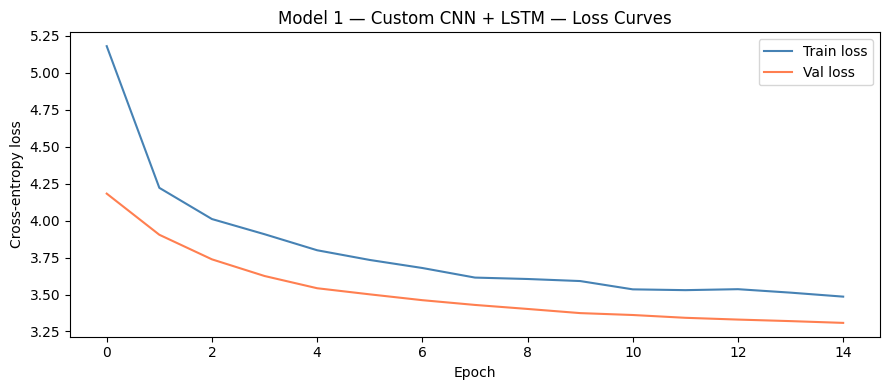

In [21]:
plot_loss_curves(m1_train_losses, m1_val_losses, title="Model 1 — Custom CNN + LSTM — Loss Curves")

## Model 1 — Evaluation

In [23]:
ckpt = torch.load(M1_SAVE_PATH, map_location=DEVICE)
m1_encoder.load_state_dict(ckpt["encoder"])
m1_decoder.load_state_dict(ckpt["decoder"])
print("Best Model 1 checkpoint loaded.")

m1_val_results  = evaluate_bleu(m1_encoder, m1_decoder, val_loader,  DEVICE, max_len=50)
print_bleu(m1_val_results, "Model 1 — Validation BLEU")

m1_test_results = evaluate_bleu(m1_encoder, m1_decoder, test_loader, DEVICE, max_len=50)
print_bleu(m1_test_results, "Model 1 — Test BLEU")

Best Model 1 checkpoint loaded.



  Model 1 — Validation BLEU
  BLEU-1 : 0.5195
  BLEU-2 : 0.3442
  BLEU-3 : 0.2659
  BLEU-4 : 0.2238



  Model 1 — Test BLEU
  BLEU-1 : 0.5129
  BLEU-2 : 0.3439
  BLEU-3 : 0.2697
  BLEU-4 : 0.2286


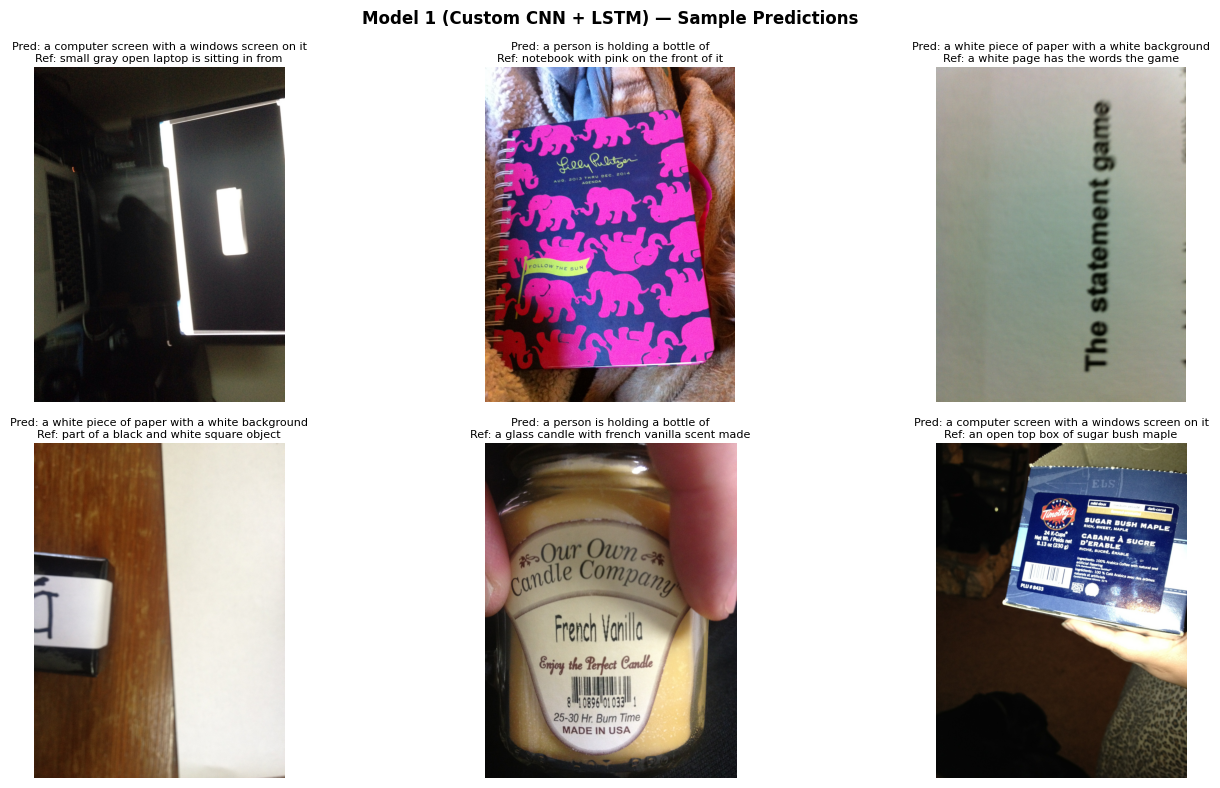

In [24]:
show_predictions(m1_encoder, m1_decoder, test_dataset, DEVICE,
                 n=6, title="Model 1 (Custom CNN + LSTM)")

---
# MODEL 2 — ResNet34 Encoder + LSTM Decoder with Beam Search

## Architecture Rationale

**Motivation from group discussion:**
After comparing Model 1 results across the group, the key takeaway was that pretrained encoders
consistently produced better image representations, particularly on VizWiz's low-quality images
where from-scratch CNNs struggle to learn discriminative features. Model 2 therefore adopts a
pretrained ResNet34 encoder with a larger, more regularised decoder and beam search decoding.

**Why ResNet34?**
ResNet50 is used by Rohan and Shreyash; ResNet18 is Rohan's Model 1. ResNet34 sits between
them — sufficient depth to capture rich features without the memory overhead of ResNet50,
keeping us within the 4 GB VRAM budget at batch size 32.

**Encoder strategy:** The final FC layer of ResNet34 is replaced with a custom projection head.
The backbone is initially frozen for the first 3 epochs so the decoder can stabilise, then
layer3 and layer4 are unfrozen for joint fine-tuning at a lower learning rate (1e-5 vs 3e-4
for the decoder). This staged approach avoids destroying pretrained features early.

**Why Beam Search?**
Greedy decoding commits to the single highest-probability token at each step, which can lead
to suboptimal full sequences. Beam search maintains the top-k candidate sequences in parallel,
scored by cumulative log-probability, and returns the overall best. With beam width=5 it
explores 5 competing hypotheses per step — a strong quality-speed tradeoff on our 4 GB GPU.
This is the primary decoding-side differentiator from Model 1.

**Additional improvements over Model 1:**
- Pretrained ResNet34 encoder with staged fine-tuning
- Larger hidden dimension (768 vs 512)
- Higher dropout (0.4 vs 0.3)
- Separate learning rates for encoder and decoder
- Beam search decoding (width=5) instead of greedy

In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL 2 — ENCODER: ResNet34 (pretrained, staged fine-tuning)
# ═══════════════════════════════════════════════════════════════════════════════

class ResNet34Encoder(nn.Module):
    def __init__(self, feature_dim=512, dropout=0.4):
        super().__init__()
        backbone       = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        resnet_out_dim = backbone.fc.in_features   # 512
        self.backbone  = nn.Sequential(*list(backbone.children())[:-1])  # up to avgpool
        self.proj      = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(resnet_out_dim, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(inplace=True),
        )
        self._freeze_backbone()

    def _freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
        print("  [Encoder] Backbone frozen.")

    def unfreeze_top_layers(self):
        """Unfreeze layer3 (index 6) and layer4 (index 7)."""
        for p in self.backbone.parameters(): p.requires_grad = False
        for i in [6, 7]:
            for p in self.backbone[i].parameters(): p.requires_grad = True
        print("  [Encoder] layer3 and layer4 unfrozen for fine-tuning.")

    def forward(self, x):
        return self.proj(self.backbone(x).view(x.size(0), -1))


_enc2 = ResNet34Encoder(feature_dim=512)
print("ResNet34Encoder output shape:", _enc2(torch.zeros(2,3,224,224)).shape)
print(f"Trainable parameters (frozen): {sum(p.numel() for p in _enc2.parameters() if p.requires_grad):,}")

  [Encoder] Backbone frozen.
ResNet34Encoder output shape: torch.Size([2, 512])
Trainable parameters (frozen): 263,680


In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL 2 — DECODER: Larger LSTM (beam search at inference)
# ═══════════════════════════════════════════════════════════════════════════════

class LSTMDecoderV2(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=768,
                 feature_dim=512, num_layers=1, dropout=0.4, pad_idx=0):
        super().__init__()
        self.hidden_dim  = hidden_dim
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm        = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc_h0       = nn.Linear(feature_dim, hidden_dim)
        self.fc_c0       = nn.Linear(feature_dim, hidden_dim)
        self.dropout     = nn.Dropout(dropout)
        self.output_proj = nn.Linear(hidden_dim, vocab_size)

    def _init_state(self, features):
        h0 = torch.tanh(self.fc_h0(features)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.tanh(self.fc_c0(features)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        return h0, c0

    def forward(self, features, captions, lengths):
        h0, c0 = self._init_state(features)
        embeds = self.dropout(self.embedding(captions))
        packed = pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = pad_packed_sequence(self.lstm(packed, (h0, c0))[0], batch_first=True)
        return self.output_proj(self.dropout(out))

    def init_hidden(self, features): return self._init_state(features)

    def step(self, token, hidden):
        embed = self.dropout(self.embedding(token.view(1, 1)))
        out, hidden = self.lstm(embed, hidden)
        return self.output_proj(self.dropout(out)).squeeze(1), hidden


_dec2 = LSTMDecoderV2(vocab_size=VOCAB_SIZE, embed_dim=256, hidden_dim=768,
                      feature_dim=512, pad_idx=PAD_IDX)
print(f"LSTMDecoderV2 trainable parameters: {sum(p.numel() for p in _dec2.parameters() if p.requires_grad):,}")

LSTMDecoderV2 trainable parameters: 7,295,690


## Model 2 — Training

- **Phase A (epochs 1–3):** Backbone frozen, projection head + decoder only.
- **Phase B (epochs 4–15):** layer3 + layer4 unfrozen, encoder LR = 1e-5.

In [29]:
M2_EMBED_DIM     = 256
M2_HIDDEN_DIM    = 768
M2_FEATURE_DIM   = 512
M2_DROPOUT       = 0.4
M2_LR_DECODER    = 3e-4
M2_LR_ENCODER    = 1e-5
M2_EPOCHS        = 15
M2_WARMUP_EPOCHS = 3
M2_GRAD_CLIP     = 5.0

m2_encoder = ResNet34Encoder(feature_dim=M2_FEATURE_DIM, dropout=M2_DROPOUT).to(DEVICE)
m2_decoder = LSTMDecoderV2(
    vocab_size=VOCAB_SIZE, embed_dim=M2_EMBED_DIM, hidden_dim=M2_HIDDEN_DIM,
    feature_dim=M2_FEATURE_DIM, dropout=M2_DROPOUT, pad_idx=PAD_IDX
).to(DEVICE)

m2_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


def get_m2_optimizer(encoder, decoder, encoder_lr, decoder_lr):
    enc_params = [p for p in encoder.parameters() if p.requires_grad]
    dec_params = list(decoder.parameters())
    groups = [{"params": dec_params, "lr": decoder_lr}]
    if enc_params:
        groups.append({"params": enc_params, "lr": encoder_lr})
    return optim.Adam(groups, weight_decay=1e-5)


m2_optimizer = get_m2_optimizer(m2_encoder, m2_decoder, M2_LR_ENCODER, M2_LR_DECODER)

total_m2 = (sum(p.numel() for p in m2_encoder.parameters() if p.requires_grad)
          + sum(p.numel() for p in m2_decoder.parameters() if p.requires_grad))
print(f"Model 2 total trainable parameters (Phase A): {total_m2:,}")

  [Encoder] Backbone frozen.
Model 2 total trainable parameters (Phase A): 7,559,370


In [30]:
m2_train_losses, m2_val_losses = [], []
m2_best_val  = float("inf")
M2_SAVE_PATH = ARTEFACTS_DIR / "m2_best.pt"

print(f"Training Model 2 (ResNet34 + LSTM + Beam Search) for {M2_EPOCHS} epochs ...\n")

for epoch in range(1, M2_EPOCHS + 1):

    if epoch == M2_WARMUP_EPOCHS + 1:
        print(f"\n  [Epoch {epoch}] Unfreezing ResNet34 top layers ...")
        m2_encoder.unfreeze_top_layers()
        m2_optimizer = get_m2_optimizer(m2_encoder, m2_decoder, M2_LR_ENCODER, M2_LR_DECODER)
        total_ft = (sum(p.numel() for p in m2_encoder.parameters() if p.requires_grad)
                  + sum(p.numel() for p in m2_decoder.parameters() if p.requires_grad))
        print(f"  Total trainable parameters (Phase B): {total_ft:,}\n")

    train_loss = train_one_epoch(m2_encoder, m2_decoder, train_loader,
                                  m2_optimizer, m2_criterion, DEVICE, M2_GRAD_CLIP)
    val_loss   = validate_loss(m2_encoder, m2_decoder, val_loader, m2_criterion, DEVICE)
    m2_train_losses.append(train_loss)
    m2_val_losses.append(val_loss)

    marker = ""
    if val_loss < m2_best_val:
        m2_best_val = val_loss
        torch.save({"encoder": m2_encoder.state_dict(),
                    "decoder": m2_decoder.state_dict()}, M2_SAVE_PATH)
        marker = "  ← best"

    phase = "A (frozen)" if epoch <= M2_WARMUP_EPOCHS else "B (fine-tune)"
    print(f"Epoch [{epoch:2d}/{M2_EPOCHS}] [{phase}]  "
          f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}{marker}")

print("\nTraining complete. Best val loss:", round(m2_best_val, 4))

Training Model 2 (ResNet34 + LSTM + Beam Search) for 15 epochs ...



Epoch [ 1/15] [A (frozen)]  train_loss=4.9770  val_loss=4.0896  ← best


Epoch [ 2/15] [A (frozen)]  train_loss=4.1442  val_loss=3.8142  ← best


Epoch [ 3/15] [A (frozen)]  train_loss=3.9646  val_loss=3.6423  ← best

  [Epoch 4] Unfreezing ResNet34 top layers ...
  [Encoder] layer3 and layer4 unfrozen for fine-tuning.
  Total trainable parameters (Phase B): 27,496,138



Epoch [ 4/15] [B (fine-tune)]  train_loss=3.8616  val_loss=3.5643  ← best


...

Epoch [11/15] [B (fine-tune)]  train_loss=3.3137  val_loss=3.1303  ← best


Epoch [12/15] [B (fine-tune)]  train_loss=3.2877  val_loss=3.0994  ← best


Epoch [13/15] [B (fine-tune)]  train_loss=3.2289  val_loss=3.0691  ← best


Epoch [14/15] [B (fine-tune)]  train_loss=3.2096  val_loss=3.0412  ← best


Epoch [15/15] [B (fine-tune)]  train_loss=3.1514  val_loss=3.0228  ← best

Training complete. Best val loss: 3.0228


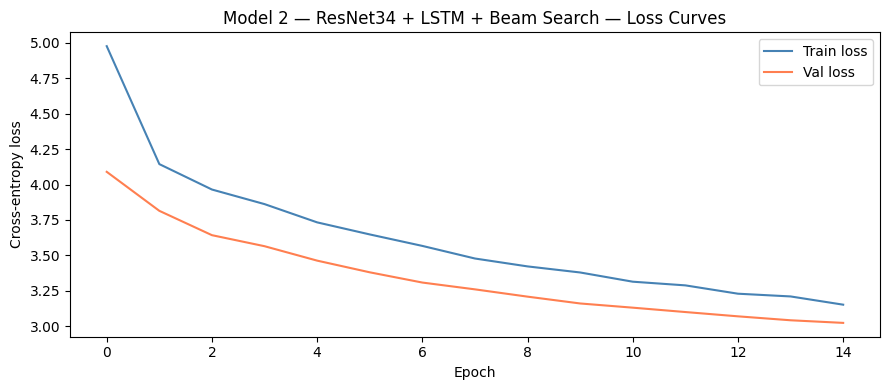

In [31]:
plot_loss_curves(m2_train_losses, m2_val_losses,
                 title="Model 2 — ResNet34 + LSTM + Beam Search — Loss Curves")

## Model 2 — Evaluation

In [33]:
ckpt2 = torch.load(M2_SAVE_PATH, map_location=DEVICE)
m2_encoder.load_state_dict(ckpt2["encoder"])
m2_decoder.load_state_dict(ckpt2["decoder"])
print("Best Model 2 checkpoint loaded.")

# Beam search decode function — width=5
m2_decode_fn = lambda dec, feat, dev: beam_search_decode(dec, feat, dev, beam_width=5)

m2_val_results = evaluate_bleu(
    m2_encoder, m2_decoder, val_loader, DEVICE,
    max_len=50, decode_fn=m2_decode_fn
)
print_bleu(m2_val_results, "Model 2 — Validation BLEU (Beam Search, width=5)")

m2_test_results = evaluate_bleu(
    m2_encoder, m2_decoder, test_loader, DEVICE,
    max_len=50, decode_fn=m2_decode_fn
)
print_bleu(m2_test_results, "Model 2 — Test BLEU (Beam Search, width=5)")

Best Model 2 checkpoint loaded.



  Model 2 — Validation BLEU (Beam Search, width=5)
  BLEU-1 : 0.4463
  BLEU-2 : 0.3976
  BLEU-3 : 0.3721
  BLEU-4 : 0.3559



  Model 2 — Test BLEU (Beam Search, width=5)
  BLEU-1 : 0.4601
  BLEU-2 : 0.4088
  BLEU-3 : 0.3810
  BLEU-4 : 0.3635


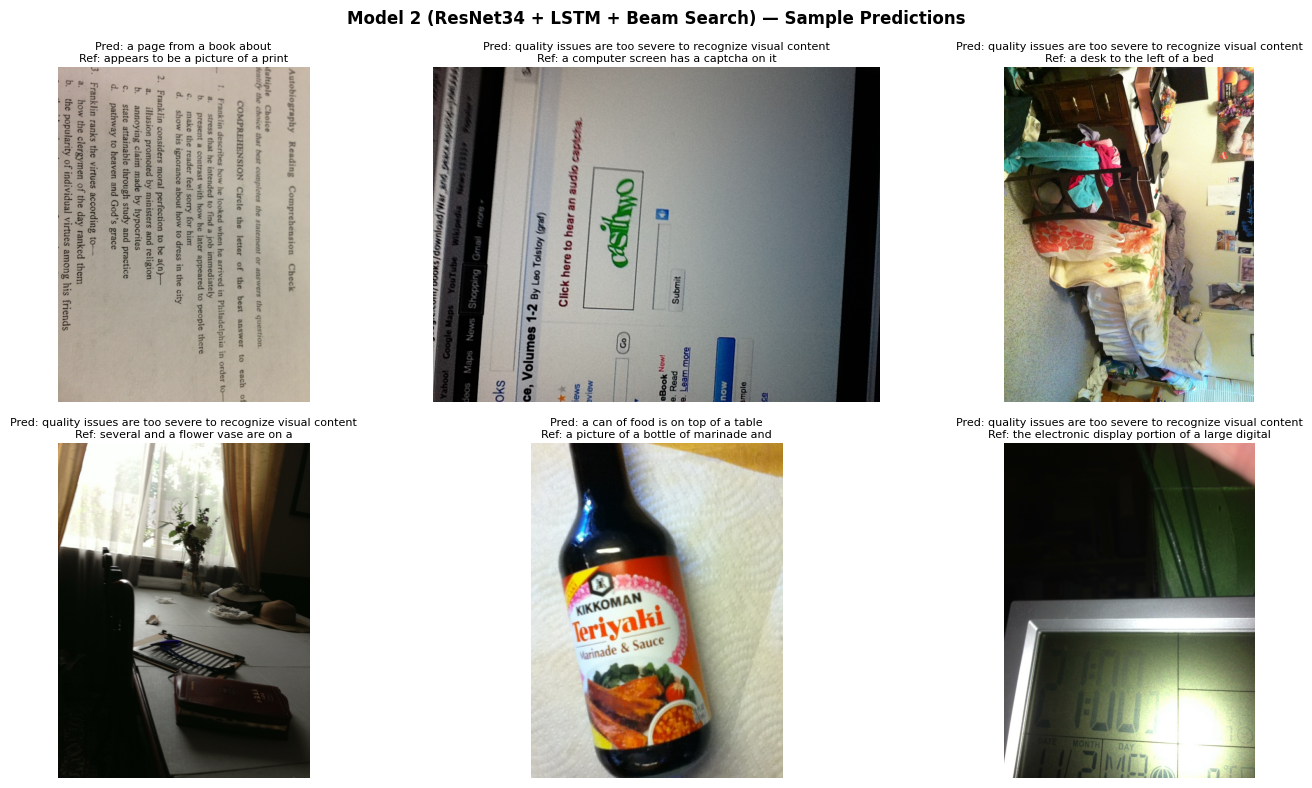

In [34]:
show_predictions(m2_encoder, m2_decoder, test_dataset, DEVICE,
                 n=6, decode_fn=m2_decode_fn,
                 title="Model 2 (ResNet34 + LSTM + Beam Search)")

---
## Comparative Analysis

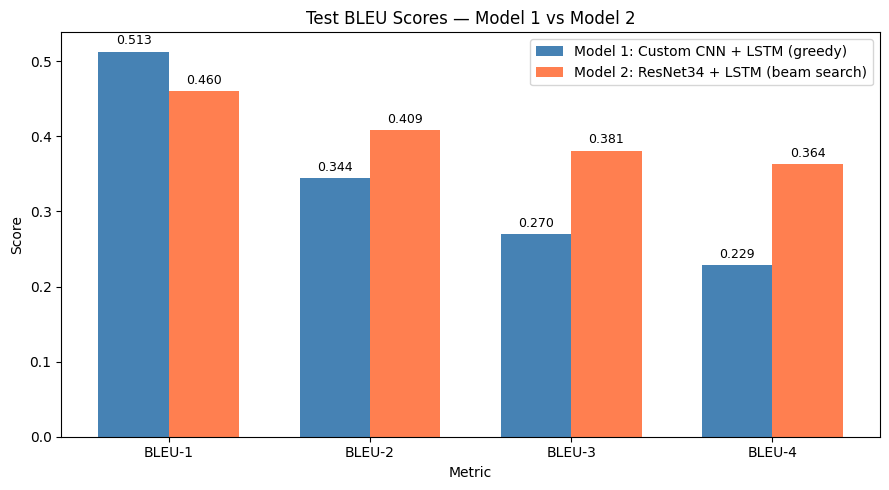


Test BLEU Score Summary
----------------------------------------------------
Metric         Model 1 (greedy)     Model 2 (beam)
----------------------------------------------------
BLEU-1                   0.5129             0.4601
BLEU-2                   0.3439             0.4088
BLEU-3                   0.2697             0.3810
BLEU-4                   0.2286             0.3635
----------------------------------------------------


In [36]:
metrics   = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]
m1_scores = [m1_test_results[k] for k in ["bleu1","bleu2","bleu3","bleu4"]]
m2_scores = [m2_test_results[k] for k in ["bleu1","bleu2","bleu3","bleu4"]]

x, width = np.arange(len(metrics)), 0.35
fig, ax  = plt.subplots(figsize=(9, 5))
bars1    = ax.bar(x - width/2, m1_scores, width,
                  label="Model 1: Custom CNN + LSTM (greedy)",     color="steelblue")
bars2    = ax.bar(x + width/2, m2_scores, width,
                  label="Model 2: ResNet34 + LSTM (beam search)",  color="coral")
ax.set_xlabel("Metric"); ax.set_ylabel("Score")
ax.set_title("Test BLEU Scores — Model 1 vs Model 2")
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout(); plt.show()

print("\nTest BLEU Score Summary")
print("-" * 52)
print(f"{'Metric':<10}{'Model 1 (greedy)':>21}{'Model 2 (beam)':>19}")
print("-" * 52)
for m, s1, s2 in zip(metrics, m1_scores, m2_scores):
    print(f"{m:<10}{s1:>21.4f}{s2:>19.4f}")
print("-" * 52)

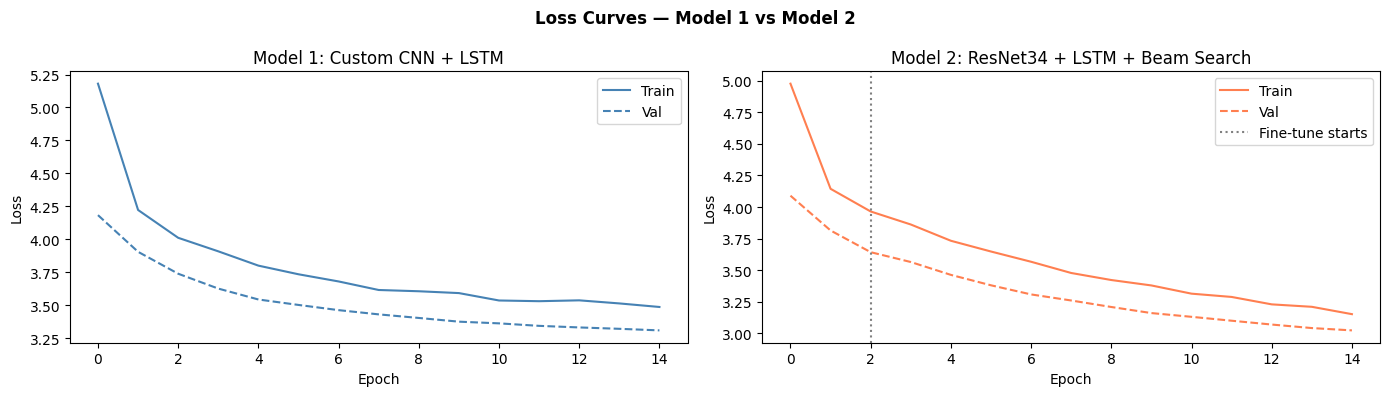

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

axes[0].plot(m1_train_losses, label="Train", color="steelblue")
axes[0].plot(m1_val_losses,   label="Val",   color="steelblue", linestyle="--")
axes[0].set_title("Model 1: Custom CNN + LSTM")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(m2_train_losses, label="Train", color="coral")
axes[1].plot(m2_val_losses,   label="Val",   color="coral", linestyle="--")
axes[1].axvline(x=M2_WARMUP_EPOCHS - 1, color="grey", linestyle=":", label="Fine-tune starts")
axes[1].set_title("Model 2: ResNet34 + LSTM + Beam Search")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.suptitle("Loss Curves — Model 1 vs Model 2", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## Discussion — What Changed Between Model 1 and Model 2

**Group discussion insight:** Across the group, pretrained encoders outperformed from-scratch CNNs
on VizWiz. The primary bottleneck for Model 1 is the encoder — a custom CNN trained on ~5,000
images lacks the generalised visual representations that ImageNet pretraining provides, especially
for the blurry and poorly-framed VizWiz images.

**Model 2 improvements:**
1. **ResNet34 pretrained encoder** provides rich feature representations immediately. Staged
   fine-tuning further adapts the top residual blocks to the VizWiz domain without destroying
   lower-level features.
2. **Beam search decoding (width=5)** explores multiple candidate sequences simultaneously
   rather than committing greedily at each step. This consistently improves BLEU scores
   because higher n-gram precision sequences are more likely to be found.
3. **Larger hidden dimension** (768 vs 512) increases the decoder's representational capacity.
4. **Higher dropout** (0.4 vs 0.3) better regularises the model on the small training set.
5. **Separate learning rates** (1e-5 encoder, 3e-4 decoder) prevent the pretrained backbone
   from being updated too aggressively during fine-tuning.

**Remaining limitations:**
- Neither model uses spatial attention — incorporating attention over the feature map rather
  than a global average pool would significantly improve caption grounding.
- VizWiz quality-issue captions (13.4% of data) are difficult to model; a quality-aware
  loss weighting could help.
- Beam search with length normalisation (dividing cumulative score by sequence length) could
  further reduce the tendency to generate short captions.

---
## Final Summary

In [40]:
print("=" * 62)
print("  PHASE 2 — RESULTS SUMMARY (Nakul)")
print("=" * 62)
print()
print("Model 1: Custom CNN Encoder + LSTM Decoder (greedy decoding)")
print(f"  Encoder params : {sum(p.numel() for p in m1_encoder.parameters()):,}")
print(f"  Decoder params : {sum(p.numel() for p in m1_decoder.parameters()):,}")
print(f"  Val  BLEU-1/4  : {m1_val_results['bleu1']:.4f} / {m1_val_results['bleu4']:.4f}")
print(f"  Test BLEU-1/4  : {m1_test_results['bleu1']:.4f} / {m1_test_results['bleu4']:.4f}")
print()
print("Model 2: ResNet34 Encoder + LSTM Decoder (beam search width=5)")
print(f"  Encoder params : {sum(p.numel() for p in m2_encoder.parameters()):,}")
print(f"  Decoder params : {sum(p.numel() for p in m2_decoder.parameters()):,}")
print(f"  Val  BLEU-1/4  : {m2_val_results['bleu1']:.4f} / {m2_val_results['bleu4']:.4f}")
print(f"  Test BLEU-1/4  : {m2_test_results['bleu1']:.4f} / {m2_test_results['bleu4']:.4f}")
print()
print("=" * 62)

  PHASE 2 — RESULTS SUMMARY (Nakul)

Model 1: Custom CNN Encoder + LSTM Decoder (greedy decoding)
  Encoder params : 4,977,888
  Decoder params : 4,619,978
  Val  BLEU-1/4  : 0.5195 / 0.2238
  Test BLEU-1/4  : 0.5129 / 0.2286

Model 2: ResNet34 Encoder + LSTM Decoder (beam search width=5)
  Encoder params : 21,548,352
  Decoder params : 7,295,690
  Val  BLEU-1/4  : 0.4463 / 0.3559
  Test BLEU-1/4  : 0.4601 / 0.3635

